In [1]:
# import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder

In [2]:
# read the veteran dataset
df = pd.read_csv('dataset_ifn580_262_v1.csv')

# show all columns information
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  string
 1   passanger             12684 non-null  string
 2   weather               12684 non-null  string
 3   temperature           12434 non-null  Int64 
 4   time                  12684 non-null  string
 5   coupon                12684 non-null  string
 6   expiration            12684 non-null  string
 7   gender                12684 non-null  string
 8   age                   12684 non-null  string
 9   maritalStatus         12684 non-null  string
 10  has_children          12684 non-null  Int64 
 11  education             12684 non-null  string
 12  occupation            12684 non-null  string
 13  income                12684 non-null  string
 14  car                   108 non-null    string
 15  Bar                   12577 non-null

In [3]:
# correlation matrix before pre-proccessing

In [4]:
# Removing NAN values from the dataset

In [5]:
# show cols with less than max / NAN values
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
print(NANcolumns_to_list)

['temperature', 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']


In [6]:
for col in NANcolumns_to_list:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)
    

Column: temperature
Amount of unique values: 4
Unique values: [55.0, 80.0, nan, 30.0]
temperature
80.0    6399
55.0    3759
30.0    2276
NaN      250
Name: count, dtype: int64
----------------------------------------
Column: car
Amount of unique values: 6
Unique values: [nan, 'Scooter and motorcycle', 'crossover', 'Mazda5', 'do not drive', 'Car that is too old to install Onstar :D']
car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64
----------------------------------------
Column: Bar
Amount of unique values: 6
Unique values: ['never', 'less1', '1~3', 'gt8', nan, '4~8']
Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64
------------------------------

In [7]:
# the car col has around %99 of its entries being NAN
print(df['car'].value_counts(dropna=False))

car
NaN                                         12576
Scooter and motorcycle                         22
Mazda5                                         22
do not drive                                   22
crossover                                      21
Car that is too old to install Onstar :D       21
Name: count, dtype: int64


In [8]:
#Best option is to drop the car col as there is too little real information within the column
df = df.drop(columns=['car'])

In [9]:
# Replace NAN values with mode for each col as the data types are currently categorical in nature
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
for col in NANcolumns_to_list:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64
----------------------------------------
CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
----------------------------------------
CarryAway
1~3      4823
4~8      4258
less1    1856
gt8      1594
never     153
Name: count, dtype: int64
----------------------------------------
RestaurantLessThan20
1~3      5506
4~8      3580
less1    2093
gt8      1285
never     220
Name: count, dtype: int64
----------------------------------------
Restaurant20To50
less1    6266
1~3      3290
never    2136
4~8       728
gt8       264
Name: count, dtype: int64
----------------------------------------


In [10]:
# Showcase the new list of nan within the dataset
NANcolumns_to_list = df.columns[df.count() < len(df)].tolist()
print(NANcolumns_to_list)

[]


In [11]:
# assigning and converting categorical datatypes to numerical

In [12]:
#listing all cols and categories
for col in df.columns:
    unique_vals = df[col].unique().tolist()  # Get each unique values within col (includes NaN)
    unique_count = len(unique_vals)          # Count the number of unique values
    
    print(f"Column: {col}")
    print(f"Amount of unique values: {unique_count}")
    print(f"Unique values: {unique_vals}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

Column: destination
Amount of unique values: 3
Unique values: ['No Urgent Place', 'Home', 'Work']
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64
----------------------------------------
Column: passanger
Amount of unique values: 4
Unique values: ['Alone', 'Friend(s)', 'Kid(s)', 'Partner']
passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64
----------------------------------------
Column: weather
Amount of unique values: 3
Unique values: ['Sunny', 'Rainy', 'Snowy']
weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64
----------------------------------------
Column: temperature
Amount of unique values: 3
Unique values: [55.0, 80.0, 30.0]
temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Column: time
Amount of unique values: 5
Unique values: ['2PM', '10AM', '6PM', '7AM', '10PM']


In [13]:
# manualing encoding the categories with an order in them
# expiration, education, , income, bar, CoffeeHouse, CarryAway, RestaurantLessThan20, Restaurant20To50

In [14]:
# Manually encoding the education col
df.loc[df['education'] == 'Some High School', 'education'] = 0
df.loc[df['education'] == 'High School Graduate', 'education'] = 1
df.loc[df['education'] == 'Some college - no degree', 'education'] = 2
df.loc[df['education'] == 'Associates degree', 'education'] = 3
df.loc[df['education'] == 'Bachelors degree', 'education'] = 4
df.loc[df['education'] == 'Graduate degree (Masters or Doctorate)', 'education'] = 5

df['education'] = df['education'].astype(int)
print(df['education'].value_counts(dropna=False).sort_index())

education
0      88
1     905
2    4351
3    1153
4    4335
5    1852
Name: count, dtype: int64


In [15]:
# Manually encoding the expiration col
df.loc[df['expiration'] == '2h', 'expiration'] = 0
df.loc[df['expiration'] == '1d', 'expiration'] = 1


df['expiration'] = df['expiration'].astype(int)
print(df['expiration'].value_counts(dropna=False).sort_index())

expiration
0    5593
1    7091
Name: count, dtype: int64


In [16]:
print(df['income'].value_counts(dropna=False).sort_index())

income
$100000 or More     1736
$12500 - $24999     1831
$25000 - $37499     2013
$37500 - $49999     1805
$50000 - $62499     1659
$62500 - $74999      846
$75000 - $87499      857
$87500 - $99999      895
Less than $12500    1042
Name: count, dtype: int64


In [17]:
# Manually encoding the income col
df.loc[df['income'] == 'Less than $12500', 'income'] = 0
df.loc[df['income'] == '$12500 - $24999', 'income'] = 12500
df.loc[df['income'] == '$25000 - $37499', 'income'] = 25000
df.loc[df['income'] == '$37500 - $49999', 'income'] = 37500
df.loc[df['income'] == '$50000 - $62499', 'income'] = 50000
df.loc[df['income'] == '$62500 - $74999', 'income'] = 62500 
df.loc[df['income'] == '$75000 - $87499', 'income'] = 75000
df.loc[df['income'] == '$87500 - $99999', 'income'] = 87500
df.loc[df['income'] == '$100000 or More', 'income'] = 100000

df['income'] = df['income'].astype(int)
print(df['income'].value_counts(dropna=False).sort_index())

income
0         1042
12500     1831
25000     2013
37500     1805
50000     1659
62500      846
75000      857
87500      895
100000    1736
Name: count, dtype: int64


In [18]:
#manually encoding all the dinner visits
print(df['Bar'].value_counts(dropna=False))

Bar
never    5304
less1    3482
1~3      2473
4~8      1076
gt8       349
Name: count, dtype: int64


In [19]:
# Manually encoding the Bar col
df.loc[df['Bar'] == 'never', 'Bar'] = 0
df.loc[df['Bar'] == 'less1', 'Bar'] = 1
df.loc[df['Bar'] == '1~3', 'Bar'] = 2
df.loc[df['Bar'] == '4~8', 'Bar'] = 3
df.loc[df['Bar'] == 'gt8', 'Bar'] = 4


df['Bar'] = df['Bar'].astype(int)
print(df['Bar'].value_counts(dropna=False).sort_index())

Bar
0    5304
1    3482
2    2473
3    1076
4     349
Name: count, dtype: int64


In [20]:
# Manually encoding the CoffeeHouse col
print(df['CoffeeHouse'].value_counts(dropna=False))
print("-" * 40)

CoffeeHouse
less1    3602
1~3      3225
never    2962
4~8      1784
gt8      1111
Name: count, dtype: int64
----------------------------------------


In [21]:
df.loc[df['CoffeeHouse'] == 'never', 'CoffeeHouse'] = 0
df.loc[df['CoffeeHouse'] == 'less1', 'CoffeeHouse'] = 1
df.loc[df['CoffeeHouse'] == '1~3', 'CoffeeHouse'] = 2
df.loc[df['CoffeeHouse'] == '4~8', 'CoffeeHouse'] = 3
df.loc[df['CoffeeHouse'] == 'gt8', 'CoffeeHouse'] = 4


df['CoffeeHouse'] = df['CoffeeHouse'].astype(int)
print(df['CoffeeHouse'].value_counts(dropna=False).sort_index())

CoffeeHouse
0    2962
1    3602
2    3225
3    1784
4    1111
Name: count, dtype: int64


In [22]:
# Manually encoding the CarryAway col

df.loc[df['CarryAway'] == 'never', 'CarryAway'] = 0
df.loc[df['CarryAway'] == 'less1', 'CarryAway'] = 1
df.loc[df['CarryAway'] == '1~3', 'CarryAway'] = 2
df.loc[df['CarryAway'] == '4~8', 'CarryAway'] = 3
df.loc[df['CarryAway'] == 'gt8', 'CarryAway'] = 4


df['CarryAway'] = df['CarryAway'].astype(int)
print(df['CarryAway'].value_counts(dropna=False).sort_index())

CarryAway
0     153
1    1856
2    4823
3    4258
4    1594
Name: count, dtype: int64


In [23]:
# Manually encoding the RestaurantLessThan20 col

df.loc[df['RestaurantLessThan20'] == 'never', 'RestaurantLessThan20'] = 0
df.loc[df['RestaurantLessThan20'] == 'less1', 'RestaurantLessThan20'] = 1
df.loc[df['RestaurantLessThan20'] == '1~3', 'RestaurantLessThan20'] = 2
df.loc[df['RestaurantLessThan20'] == '4~8', 'RestaurantLessThan20'] = 3
df.loc[df['RestaurantLessThan20'] == 'gt8', 'RestaurantLessThan20'] = 4


df['RestaurantLessThan20'] = df['RestaurantLessThan20'].astype(int)
print(df['RestaurantLessThan20'].value_counts(dropna=False).sort_index())

RestaurantLessThan20
0     220
1    2093
2    5506
3    3580
4    1285
Name: count, dtype: int64


In [24]:
# Manually encoding the Restaurant20To50 col

df.loc[df['Restaurant20To50'] == 'never', 'Restaurant20To50'] = 0
df.loc[df['Restaurant20To50'] == 'less1', 'Restaurant20To50'] = 1
df.loc[df['Restaurant20To50'] == '1~3', 'Restaurant20To50'] = 2
df.loc[df['Restaurant20To50'] == '4~8', 'Restaurant20To50'] = 3
df.loc[df['Restaurant20To50'] == 'gt8', 'Restaurant20To50'] = 4


df['Restaurant20To50'] = df['Restaurant20To50'].astype(int)
print(df['Restaurant20To50'].value_counts(dropna=False).sort_index())

Restaurant20To50
0    2136
1    6266
2    3290
3     728
4     264
Name: count, dtype: int64


In [25]:
# Manually encoding the gender col


df.loc[df['gender'] == 'Female', 'gender'] = 0
df.loc[df['gender'] == 'Male', 'gender'] = 1



df['gender'] = df['gender'].astype(int)
print(df['gender'].value_counts(dropna=False).sort_index())

gender
0    6511
1    6173
Name: count, dtype: int64


In [26]:
# Manually encoding the age col
print(df['age'].value_counts(dropna=False))

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64


In [27]:
df.loc[df['age'] == 'below21', 'age'] = 16
df.loc[df['age'] == '21', 'age'] = 21
df.loc[df['age'] == '26', 'age'] = 26
df.loc[df['age'] == '31', 'age'] = 31
df.loc[df['age'] == '36', 'age'] = 36
df.loc[df['age'] == '41', 'age'] = 41
df.loc[df['age'] == '46', 'age'] = 46
df.loc[df['age'] == '50plus', 'age'] = 51


df['age'] = df['age'].astype(int)
print(df['age'].value_counts(dropna=False).sort_index())

age
16     547
21    2653
26    2559
31    2039
36    1319
41    1093
46     686
51    1788
Name: count, dtype: int64


In [28]:
print(df['time'].value_counts(dropna=False).sort_index())

time
10AM    2275
10PM    2006
2PM     2009
6PM     3230
7AM     3164
Name: count, dtype: int64


In [29]:
df.loc[df['time'] == '7AM', 'time'] = 7
df.loc[df['time'] == '10AM', 'time'] = 10
df.loc[df['time'] == '2PM', 'time'] = 14
df.loc[df['time'] == '6PM', 'time'] = 18
df.loc[df['time'] == '10PM', 'time'] = 22



df['time'] = df['time'].astype(int)
print(df['time'].value_counts(dropna=False).sort_index())

time
7     3164
10    2275
14    2009
18    3230
22    2006
Name: count, dtype: int64


# Removing highly correlated values

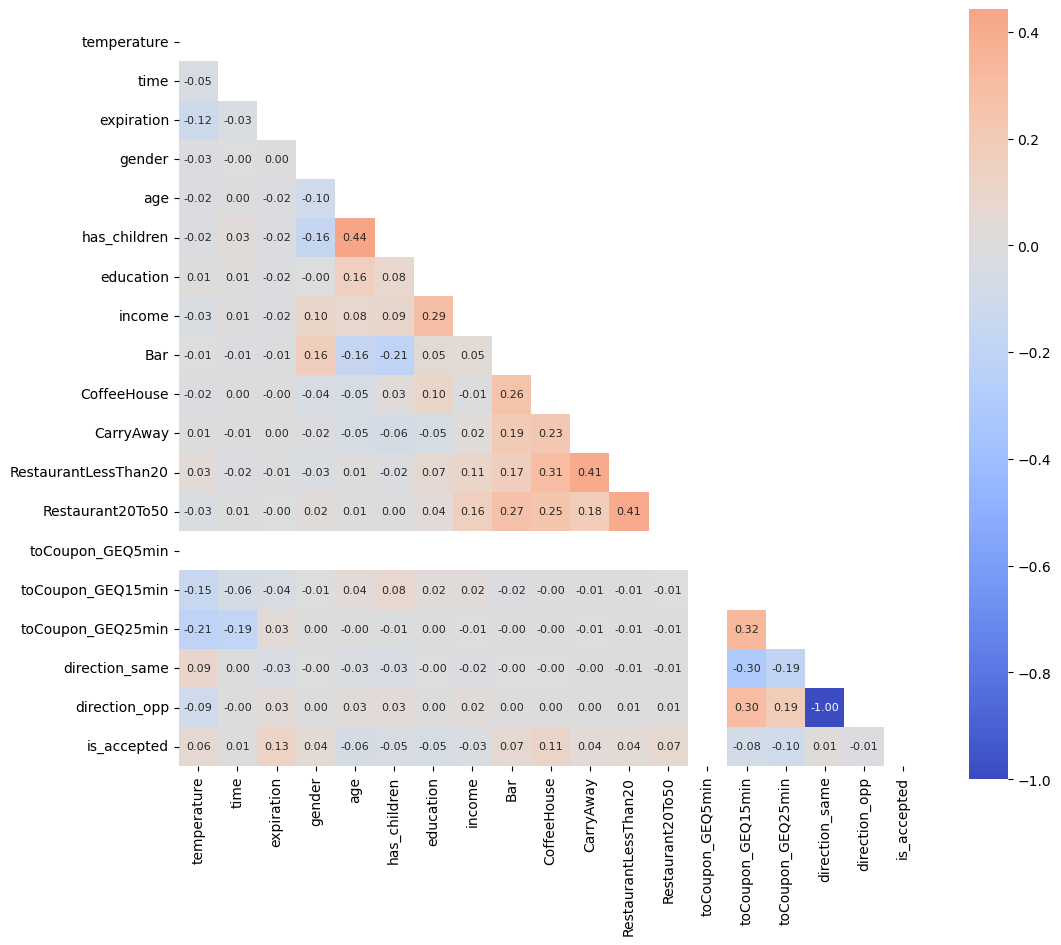

In [30]:
# Select only columns with numerical values.
numerical_columns = df.select_dtypes(include=['number'])

# Display the correlation matrix.
correlation_matrix = numerical_columns.corr()

# Create a mask for the upper triangle to avoid duplicate data
correlation_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
plt.figure(figsize=(12, 10))
# annot=True tells seaborn to display the values for each cell.
# fmt=".2f" tells seaborn to round the values to 2 decimal places, otherwise it would not fit in the cells.
# We also adjust the font size so it fits in the page (annot_kws={'size': 8})
# center=0 tells seaborn that the middle point of the heatmap should be zero.
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
annot_kws={'size': 8}, cmap='coolwarm',
center=0, mask=correlation_mask, square=True)
plt.show()

In [31]:
del df['direction_opp']

In [32]:
#Find the tpes of data within 
mixed_type_cols = []
for col in df.columns:
    print(df[col].apply(type).value_counts())
    print("-" * 40)
    unique_types = df[col].apply(type).value_counts()
    if len(unique_types) > 1:
        mixed_type_cols.append(col)

destination
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
passanger
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
weather
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
temperature
<class 'float'>    12684
Name: count, dtype: int64
----------------------------------------
time
<class 'int'>    12684
Name: count, dtype: int64
----------------------------------------
coupon
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
expiration
<class 'int'>    12684
Name: count, dtype: int64
----------------------------------------
gender
<class 'int'>    12684
Name: count, dtype: int64
----------------------------------------
age
<class 'int'>    12684
Name: count, dtype: int64
----------------------------------------
maritalStatus
<class 'str'>    12684
Name: count, dtype: int64
----------------------------------------
has_chil

In [33]:
# find cols with multiple data types

print('Columns with multiple object types:', mixed_type_cols)

Columns with multiple object types: []


# Assign Data Types

In [34]:
## looking at what kind of values can be found in each column
for name in df.columns:
    print(f'_{name}________________________________________')
    print(df[name].unique())

_destination________________________________________
['No Urgent Place' 'Home' 'Work']
_passanger________________________________________
['Alone' 'Friend(s)' 'Kid(s)' 'Partner']
_weather________________________________________
['Sunny' 'Rainy' 'Snowy']
_temperature________________________________________
[55. 80. 30.]
_time________________________________________
[14 10 18  7 22]
_coupon________________________________________
['Restaurant(<20)' 'Coffee House' 'Carry out & Take away' 'Bar'
 'Restaurant(20-50)']
_expiration________________________________________
[1 0]
_gender________________________________________
[0 1]
_age________________________________________
[21 46 26 31 41 51 36 16]
_maritalStatus________________________________________
['Unmarried partner' 'Single' 'Married partner' 'Divorced' 'Widowed']
_has_children________________________________________
[1 0]
_education________________________________________
[2 4 3 1 5 0]
_occupation______________________________________

## Hot encoding remaining categories
the remaining categories need to be hot encoded for their values and data to work within the various learning models



In [35]:
# show all columns information with updated types
print(df.convert_dtypes().info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  string
 1   passanger             12684 non-null  string
 2   weather               12684 non-null  string
 3   temperature           12684 non-null  Int64 
 4   time                  12684 non-null  Int64 
 5   coupon                12684 non-null  string
 6   expiration            12684 non-null  Int64 
 7   gender                12684 non-null  Int64 
 8   age                   12684 non-null  Int64 
 9   maritalStatus         12684 non-null  string
 10  has_children          12684 non-null  Int64 
 11  education             12684 non-null  Int64 
 12  occupation            12684 non-null  string
 13  income                12684 non-null  Int64 
 14  Bar                   12684 non-null  Int64 
 15  CoffeeHouse           12684 non-null

# checking for data quality issues

In [36]:
def show_unique_values(df):
    for column_name in df:
        unique_values = df[column_name].value_counts(dropna=False)
        print(f"Unique values and their counts for column '{column_name}':\n{unique_values}")
        print("-" * 40)


In [37]:
show_unique_values(df)

Unique values and their counts for column 'destination':
destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64
----------------------------------------
Unique values and their counts for column 'passanger':
passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64
----------------------------------------
Unique values and their counts for column 'weather':
weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64
----------------------------------------
Unique values and their counts for column 'temperature':
temperature
80.0    6649
55.0    3759
30.0    2276
Name: count, dtype: int64
----------------------------------------
Unique values and their counts for column 'time':
time
18    3230
7     3164
10    2275
14    2009
22    2006
Name: count, dtype: int64
----------------------------------------
Unique values and their counts for column 'coupon':
coupon
Coff

In [38]:
print(df['destination'].value_counts(dropna=False).sort_index())

destination
Home               3237
No Urgent Place    6283
Work               3164
Name: count, dtype: int64


In [39]:
df['destination'] = pd.factorize(df['destination'])[0]

print(df['destination'].value_counts(dropna=False).sort_index())

destination
0    6283
1    3237
2    3164
Name: count, dtype: int64


In [40]:
df['passanger'] = pd.factorize(df['passanger'])[0]

print(df['passanger'].value_counts(dropna=False).sort_index())

passanger
0    7305
1    3298
2    1006
3    1075
Name: count, dtype: int64


In [41]:
df['weather'] = pd.factorize(df['weather'])[0]
print(df['weather'].value_counts(dropna=False).sort_index())

weather
0    10069
1     1210
2     1405
Name: count, dtype: int64


In [42]:
df['coupon'] = pd.factorize(df['coupon'])[0]
print(df['coupon'].value_counts(dropna=False).sort_index())

coupon
0    2786
1    3996
2    2393
3    2017
4    1492
Name: count, dtype: int64


In [43]:
df['maritalStatus'] = pd.factorize(df['maritalStatus'])[0]
print(df['maritalStatus'].value_counts(dropna=False).sort_index())

maritalStatus
0    2186
1    4752
2    5100
3     516
4     130
Name: count, dtype: int64


In [44]:
df['occupation'] = pd.factorize(df['occupation'])[0]
print(df['occupation'].value_counts(dropna=False).sort_index())

occupation
0     1870
1      175
2     1584
3      943
4      242
5      244
6     1093
7      838
8      629
9     1408
10     170
11     175
12     241
13     639
14     154
15     219
16     495
17     133
18     218
19     544
20     175
21     298
22     110
23      44
24      43
Name: count, dtype: int64


In [45]:
df['occupation'] = pd.factorize(df['occupation'])[0]
print(df['occupation'].value_counts(dropna=False).sort_index())

occupation
0     1870
1      175
2     1584
3      943
4      242
5      244
6     1093
7      838
8      629
9     1408
10     170
11     175
12     241
13     639
14     154
15     219
16     495
17     133
18     218
19     544
20     175
21     298
22     110
23      44
24      43
Name: count, dtype: int64


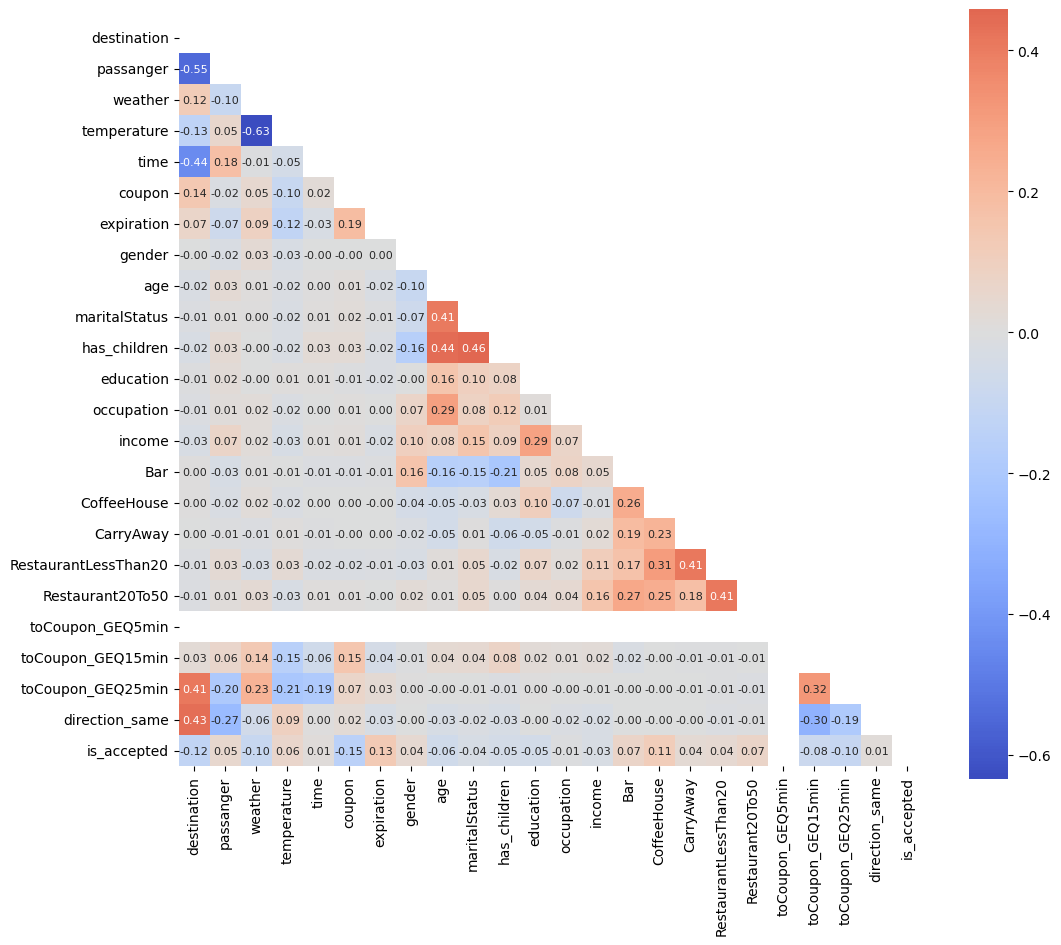

In [46]:
# Select only columns with numerical values.
numerical_columns = df.select_dtypes(include=['number'])

# Display the correlation matrix.
correlation_matrix = numerical_columns.corr()

# Create a mask for the upper triangle to avoid duplicate data
correlation_mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
plt.figure(figsize=(12, 10))
# annot=True tells seaborn to display the values for each cell.
# fmt=".2f" tells seaborn to round the values to 2 decimal places, otherwise it would not fit in the cells.
# We also adjust the font size so it fits in the page (annot_kws={'size': 8})
# center=0 tells seaborn that the middle point of the heatmap should be zero.
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
annot_kws={'size': 8}, cmap='coolwarm',
center=0, mask=correlation_mask, square=True)
plt.show()

In [47]:
df.to_csv('PreProcesseddataset_ifn580_262_v1.csv', index=False)